In [1]:
# recursos necesarios
# pip install pandas numpy scikit-learn scipy graphviz matplotlib

# Usar el siguiente comando si se trabaja desde una maquina Ubuntu/Debian
# sudo apt-get install graphviz

# %% [markdown]
# # Clasificación con Bosques Aleatorios (Random Forest) en Python

In [2]:
# %% [markdown]
# ## 1. Importación de librerías
# %%
# Proceso de datos
import pandas as pd
import numpy as np

# Modelado
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Visualización de árboles
from sklearn.tree import export_graphviz
from IPython.display import Image

import os
# Añade la ruta de Graphviz a tu PATH
os.environ["PATH"] += r";C:\Program Files\Graphviz\bin"

import graphviz

In [3]:
# %% [markdown]
# ## 2. Carga de datos

# %%
bank_data = pd.read_csv(
    r'C:\Users\Ryzen 5\Desktop\RandomForest Example\resources\bank_sintetico.csv',
    sep=';'
) # reemplaza con la ruta donde coloques el archivo de los recursos

bank_data.head()

,age,default,cons.price.idx,cons.conf.idx,y
0,56,no,94.087,-32.3,no
1,69,no,94.575,-36.2,no
2,46,no,92.978,-42.6,no
3,32,no,92.661,-39.5,no
4,60,no,94.133,-43.6,no


In [4]:
# %% [markdown]
# ## 2. Preprocesamiento de datos

# %%
bank_data['default'] = bank_data['default'].map({'no': 0, 'yes': 1, 'unknown': 0})
bank_data['y'] = bank_data['y'].map({'no': 0, 'yes': 1})

In [5]:
# %% [markdown]
# ## 3. División de datos en entrenamiento y prueba

# %%
# Divide los datos en características (X) y objetivo (y)
X = bank_data.drop('y', axis=1)
y = bank_data['y']

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
# %% [markdown]
# ## 4. Entrenamiento del modelo base

# %%
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9


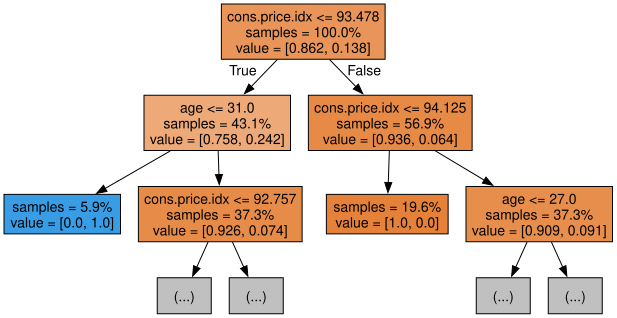

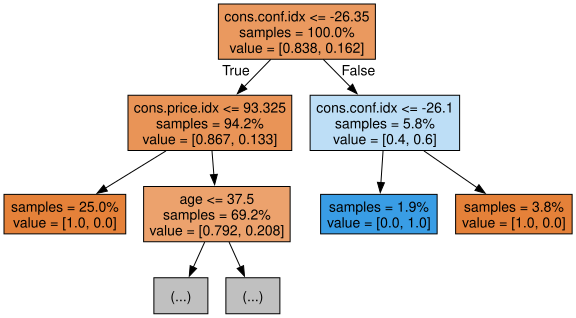

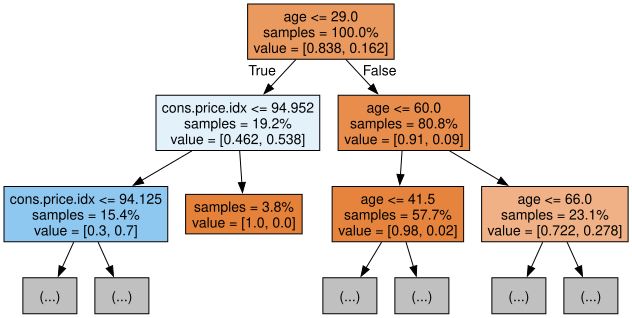

In [7]:
# %% [markdown]
# ## 5. Visualización de los primeros 3 árboles

# %%
# Exporta los primeros tres árboles de decisión del bosque
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)